# Neural Probablistic Language Model - Character Level

The model implemented here is based on paper on Neural Probablistic Language Model - 2003. This is not the first paper proposing use of MLP for Language model but it is a very influential paper. Link to paper https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf. 

The paper proposes a word level language model for vocabulary of 17000 words. 
The 17000 words are encoded or represented by a 30 dimension feature vector. This embedding representation for words start with random initalization and slowly learned via backpropagation and gradient descent, during model training. The model learns to predict the next word given previous words with the objective of maximizing the log likelihood of training data (or minimizing negative log likelihood) with regularized weights (weight decay penalty). This embedding representation for words can also start with prior knowledge of semantic features (say co-occurance reduced via SVD). After full training we can expect words meaning similar things reside closer in the 30 dimensional space and words that are not semantically similar go far away in the 30 dimensional space.

We use the approach in this paper to create a character level language model for vocabulary of 27 characters represented by 2 dimensional embeddings

Pytorch provides many functions to manipulate the tensors. Reference to blog on Pytorch internals that talk about how tensors are stored and operated under the hood to have a better understanding on efficiencies in pytorch
https://blog.ezyang.com/2019/05/pytorch-internals/


Reference Andrej Karapathy: https://www.youtube.com/watch?v=TCH_1BHY58I&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=3&pp=iAQB


##### Side note: How are embeddings generated for unseen words
Word2Vec / GloVe (Static) Models crete One vector for all meanings and error out with "Out of Vocabulary" error. Contextual models like GPT/BERT (transformer based models) use sub-word units and context to "guess."
GPT is unidirectional autoregressive BERT is bidirectional looks at words after and before to create a context for the word. GPT - though only looks backwards to create context, its massive scale allows it to "predict" the meaning of a new word based on the patterns of the preceding sentence

a) Unknown Token: In older or simpler models, mapped unseen words to 'Uknown' token, which has embedding calculated as average of all rare word vectors

b) Subword tokenization or character level tokenization: 
- BERT uses subword tokenization to divide unknown words into smaller units.
- FastText break words into known n-grams, to construct embedding by averaging embeddings of known subwords
- Bidirectional Long Short-Term Memory generate representation for entire word based on its character spelling

c) Contextual Inference: contextual models can infer meaning from surrounding words.

In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [19]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
words[:8]

32033


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [27]:
# build the vocabulary of characters and mappings from/to integers
chs = sorted(set(''.join(words)))
stoi = {s: i+1 for i, s in enumerate(chs)}
stoi['.'] = 0
itos = {i: s for s,i in stoi.items()}
print(itos)

# build the training dataset of 3 input characters and next char as target
block_size = 3 # context length: how many characters do we take to predict the next one?
xs = []
ys = []
for w in words[:2]: # for first sample runs
    print(w)
    context = [0] * block_size
    for c in (w + '.'):
        xs.append(context)
        ix = stoi[c]
        ys.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(xs)
Y = torch.tensor(ys)
X.shape, X.dtype, Y.shape, Y.dtype



{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
one hot encoding product:  tensor([ 1.8000, -0.6687])
Reference to C:  tensor([ 1.8000, -0.6687]) tensor([-0.5114,  0.6255]) tensor([-0.5396,  1.8939])
refer arrays of ix: tensor([[ 1.8000, -0.6687],
        [-0.5114,  0.6255],
        [-0.5396,  1.8939]])
refer tensor of ix: tensor([[ 1.8000, -0.6687],
        [-0.5114,  0.6255],
        [-0.5396,  1.8939]])
refer tensor of ix shape: torch.Size([3, 2])
refer multidimenstional tensor shape: torch.Size([4, 3, 2])
refer multidimenstional tensor shape: tensor([-0.5114,  0.6255])
torch.Size([12, 3, 2])


In [29]:
# Consider C is shared embedding matrix for each character of dimension size 2
C = torch.randn((27, 2))
emb = C[X]

# One way to map the characters in X to corresponding embeddings is dot product
# This dot product retains only the entries of row ix in C
# The second way is to pick the row from C at that index. This is faster
ix = 5
one_hot_c = F.one_hot(torch.tensor(ix), num_classes =27).float()
print("one hot encoding product: ",one_hot_c @ C)
print("Reference to C: ", C[ix], C[ix+2], C[ix+3]) # indexes 5, 7, 8 
# if ix is an array of indexes or a tensor of indexes
print(f"refer arrays of ix: {C[[5, 7, 8]]}")
print(f"refer tensor of ix: {C[torch.tensor([5, 7, 8])]}")
print(f"refer tensor of ix shape: {C[torch.tensor([5, 7, 8])].shape}")
print(f"refer multidimenstional tensor shape: {C[torch.tensor([[5, 7, 8],[1, 0, 0],[1, 2, 3],[4, 5, 5]])].shape}")
print(f"refer multidimenstional tensor shape: {C[torch.tensor([[5, 7, 8],[1, 0, 0],[1, 2, 3],[4, 5, 5]])][0,1]}")
print(C[X].shape)

one hot encoding product:  tensor([-0.9745, -1.2303])
Reference to C:  tensor([-0.9745, -1.2303]) tensor([-0.3342, -1.3729]) tensor([ 0.0106, -1.4720])
refer arrays of ix: tensor([[-0.9745, -1.2303],
        [-0.3342, -1.3729],
        [ 0.0106, -1.4720]])
refer tensor of ix: tensor([[-0.9745, -1.2303],
        [-0.3342, -1.3729],
        [ 0.0106, -1.4720]])
refer tensor of ix shape: torch.Size([3, 2])
refer multidimenstional tensor shape: torch.Size([4, 3, 2])
refer multidimenstional tensor shape: tensor([-0.3342, -1.3729])
torch.Size([12, 3, 2])


In [121]:
# The embeddings of the 3 inputs characters should be concatenated and 
# fully connected to the next hidden layer
# Let the dimension of the next hidden layer be 100 units
# Each unit in the hidden layer will be connected to each of 6 units in concatenated embedding input
# Weights of hidden layer = 6 X 100
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
# -1 implies let pytorch interpret the dimension - can be used for one of the dims only
# first dimension of emb can be kept as emb.shape[0]; so it adjusts to higher number of examples
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # each value is between -1 and 1
# note on broadcast always check the operation is as intended
# here E@W + b is 12:100::none:100. b is a single row of 100 units; broadcast 12 times, to each row
# each output hidden unit needs a bias
print("hidden layer: ", h.shape)

# final layer
W2 = torch.randn((100, 27))
b2 = torch.randn((1, 27))
logits = h @ W2 + b2 # number of inputs X 27
print("logits shape: ", logits.shape)
count_eqv = logits.exp() # this and next step is softmax calculations
probs = count_eqv / count_eqv.sum(axis=1, keepdims=True) # want a column of values by sum so axis = 1
# average of y log(y_pred) across all samples
loss = probs[torch.arange(probs.shape[0]), Y].log().mean() # pick predicted prob at index of y target
nll = -loss
print(f"from calculations: {nll}")
print(f"from cross entropy function: {F.cross_entropy(logits, Y)}")
print(torch.tensor([-100, -50, 2, 5, 89]).float().exp())

hidden layer:  torch.Size([12, 100])
logits shape:  torch.Size([12, 27])
from calculations: 21.92621421813965
from cross entropy function: 21.92621612548828
tensor([3.7835e-44, 1.9287e-22, 7.3891e+00, 1.4841e+02,        inf])


##### Cross Entropy Loss in Pytorch: 
Pytorch has library to calculate soft max and provides loss for binary and multiclass classification
There are multiple advantages to using pytorch libraries.

- The forward pass is calculated more efficiently. With logits, exp, probabilities we create a new tensor for each. Pytorch does not create intermediate tensors. It clusters these operations efficiently and creates fused kernels to run them (lesser trips from VRAM to memory)    
- The backward pass also becomes efficient with lower operations as well as more efficient mathematical gradient calculations. Example gradient of tanh can be calculated as 1-tanh(x)^2 and softmax gradient can be efficiently calculated as y_pred - y_true. These calculations are more efficient than going backward through a more detailed computation graph that we create by calculating exp, log, mean etc
- The library also adds other efficiencies for numerical stability. Example, to manage very high or low weights. Example exp of -100 is a very small number and of +100 is 'inf' as it runs out of range of floating point numbers. The exp curve goes to zero asymptotically for large negative values of x, is at 1 when x = 0 and shoots up toward inf in positive range. Log calculations of 'inf' is not defined as returns 'nan'. Pytorch works around this by fetching max of tensor values and subtracting each tensor value by max to convert all values in tensor to < 0 for which exp and log values can be calculated. This is because any offset to logits provides the exact same probabilities. 
    
So in place of logits.exp, normalizing, calculating negative log likelihood loss use pytorch library function of binary cross entropy for binary classification and cross entropy loss for multiclass classification

In [117]:
# any offset to logits provides the exact same probabilities
logit = torch.tensor([-5, 2, 5])
exp_c = logit.exp()
probs = exp_c / exp_c.sum()
print(probs)

logit = torch.tensor([-5, 2, 5]) - 2
exp_c = logit.exp()
probs = exp_c / exp_c.sum()
print(probs)

logit = torch.tensor([-5, 2, 5]) - 5
exp_c = logit.exp()
probs = exp_c / exp_c.sum()
print(probs)

logit = torch.tensor([-500, 400, 500]) - 500 # subract by max of tensor
exp_c = logit.exp()
probs = exp_c / exp_c.sum()
print(probs)

tensor([4.3245e-05, 4.7424e-02, 9.5253e-01])
tensor([4.3245e-05, 4.7424e-02, 9.5253e-01])
tensor([4.3245e-05, 4.7424e-02, 9.5253e-01])
tensor([0.0000e+00, 3.7835e-44, 1.0000e+00])


In [81]:
# Size of embeddings are torch.Size([Inputs, 3, 2])
# concatenate: along 0 rows one below other by default. 
# Assign axis = 1 to concatenate along cols side by side
print(torch.concat((emb[:,0,:], emb[:, 1, :], emb[:, 2, :]), dim=1)) 
#unbind removes/peels the dim and gives a tuple of tensors without that dim
print(emb.unbind(dim=1))
# concatenate creates a new tensor in new memory storage
print(torch.concat(emb.unbind(dim=1), axis=1)) # concat the peeled tensors side by side
# views are efficient, do not manipulate memory storage or create copies
# they just change the attributes of storage offset, strides, shapes that allow the 
# one dimensional storage vector to be interpreted as n dimensional tensor
print(emb.view((12,6))) 
print(emb.view((-1,6))==torch.concat(emb.unbind(dim=1), axis=1)) # compare if they are same

tensor([[ 1.1478,  0.3415,  1.1478,  0.3415,  1.1478,  0.3415],
        [ 1.1478,  0.3415,  1.1478,  0.3415, -0.9745, -1.2303],
        [ 1.1478,  0.3415, -0.9745, -1.2303, -0.8485,  0.7061],
        [-0.9745, -1.2303, -0.8485,  0.7061, -0.8485,  0.7061],
        [-0.8485,  0.7061, -0.8485,  0.7061,  1.4267,  0.5559],
        [ 1.1478,  0.3415,  1.1478,  0.3415,  1.1478,  0.3415],
        [ 1.1478,  0.3415,  1.1478,  0.3415, -1.0055,  0.7505],
        [ 1.1478,  0.3415, -1.0055,  0.7505,  0.4230, -0.2316],
        [-1.0055,  0.7505,  0.4230, -0.2316, -0.3230, -0.5465],
        [ 0.4230, -0.2316, -0.3230, -0.5465, -0.7321, -0.3005],
        [-0.3230, -0.5465, -0.7321, -0.3005, -0.3230, -0.5465],
        [-0.7321, -0.3005, -0.3230, -0.5465,  1.4267,  0.5559]])
(tensor([[ 1.1478,  0.3415],
        [ 1.1478,  0.3415],
        [ 1.1478,  0.3415],
        [-0.9745, -1.2303],
        [-0.8485,  0.7061],
        [ 1.1478,  0.3415],
        [ 1.1478,  0.3415],
        [ 1.1478,  0.3415],
      

##### Side note: Tensor storage and Views
In computer memory, each tensor is stored as one dimensional vector. It can be seen in different views. Views are efficient (better than unbind, concat) do not manipulate memory storage or create copies. They just change the attributes of storage offset, strides, shapes that allow the one dimensional storage vector to be interpreted as n-dimensional tensor
Reference to blog on Pytorch internals how tensors are stored and operated under the hood 
https://blog.ezyang.com/2019/05/pytorch-internals/

In [75]:

emb.storage() 


 1.1477577686309814
 0.3415013551712036
 1.1477577686309814
 0.3415013551712036
 1.1477577686309814
 0.3415013551712036
 1.1477577686309814
 0.3415013551712036
 1.1477577686309814
 0.3415013551712036
 -0.9744648933410645
 -1.230322003364563
 1.1477577686309814
 0.3415013551712036
 -0.9744648933410645
 -1.230322003364563
 -0.8485152125358582
 0.7061477899551392
 -0.9744648933410645
 -1.230322003364563
 -0.8485152125358582
 0.7061477899551392
 -0.8485152125358582
 0.7061477899551392
 -0.8485152125358582
 0.7061477899551392
 -0.8485152125358582
 0.7061477899551392
 1.4266644716262817
 0.5558742880821228
 1.1477577686309814
 0.3415013551712036
 1.1477577686309814
 0.3415013551712036
 1.1477577686309814
 0.3415013551712036
 1.1477577686309814
 0.3415013551712036
 1.1477577686309814
 0.3415013551712036
 -1.0054856538772583
 0.7504634261131287
 1.1477577686309814
 0.3415013551712036
 -1.0054856538772583
 0.7504634261131287
 0.4229693114757538
 -0.23156963288784027
 -1.0054856538772583
 0.7504

In [82]:
a = torch.arange(18)
a.view(-1,2,3)

tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17]]])

In [133]:
#-------------Putting it together -------------------#
print(f"X.shape: {X.shape} Y.shape: {Y.shape}")
# Consider C is shared embedding matrix for each character of dimension size 2
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2] # gradient descent on all of them
print(sum(p.nelement() for p in parameters))

X.shape: torch.Size([12, 3]) Y.shape: torch.Size([12])
3481


In [140]:
# prepare to learn gradients
for p in parameters:
    p.requires_grad = True

for _ in range(10):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    for p in parameters:
        p.data += -0.1 * p.grad
print(logits.max(axis = 1)) # gives both the max value and the tensor index of max
print(f"labels: {Y}")
logits[:5]

0.13944201171398163
0.13897062838077545
0.13851721584796906
0.13808058202266693
0.13765990734100342
0.13725443184375763
0.13686315715312958
0.13648556172847748
0.13612081110477448
0.135768324136734
torch.return_types.max(
values=tensor([15.4061, 16.5668, 20.0463, 15.1747, 15.6853, 15.4061, 15.7306, 15.6004,
        14.9560, 15.6006, 13.0278, 19.2751], grad_fn=<MaxBackward0>),
indices=tensor([15, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0]))
labels: tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0])


tensor([[ 10.2133,  11.4418,   2.9742,   2.3469,  -1.7973,  15.4051, -22.7970,
          10.5833,  -1.9606,   9.0648,   6.5356,   5.2300,   5.3952,  11.3006,
           4.1494,  15.4061,   7.0065,   4.2740,   1.2204,   1.1874,   3.9890,
           7.4818,  -8.7631,  -3.9934,   6.8653,  -5.8502,   7.7117],
        [ -2.4977,   3.6469,   1.2337,  -0.4188,  10.3856,  11.3670,  -2.2220,
           7.2005,   9.5067,  -2.6632,   9.3395,   1.2281,  12.6856,  16.5668,
           7.0978,   5.9304,   7.6555,  10.1090,   6.3206,   1.0388,  -4.8874,
          -9.5365, -13.4014,  -6.8865,  -0.5952,   5.3980,  10.4439],
        [  0.7722,   7.3309,  14.4352,   1.9301,  -2.0905,   9.3404,  -7.6300,
          -7.7894,  -9.5568,  13.8376,  12.9658,  10.8032,   8.9280,  20.0463,
          -7.8839,  10.3807,  -7.9227,  -8.9072,  -3.1202, -12.5139,  -8.5763,
          -8.7774,  -1.1039,  14.4192,   6.8063,  -9.6314,  -3.2547],
        [ 10.0471,  15.1747,   6.2311,  -3.8197, -11.9655,   5.8142,  -2.2954,


Loss with few samples 12 gives a loss of 0.9 and with many more epochs goes very low. This is because we are fitting model with 3000 parameters to 12 data samples. 

With only 12 examples the loss is not zero because in the 27 logits we see there are certain Y that are low prob in respective logits - like '.' at index 0. First Y = 5 but predicted 15 above. This is because '...' start is coupled with 'e', with 'o'. So it is not able to overfit such cases where the combination has multiple outputs. But where an input has one output it overfits into them.

The model overfits / memorize to each data in training set, but with new examples, out of distribution, it will generalize badly and give high loss. Lets increase the training dataset size

In [193]:
# -------------- Training with full data -------------------
# build the vocabulary of characters and mappings from/to integers
chs = sorted(set(''.join(words)))
stoi = {s: i+1 for i, s in enumerate(chs)}
stoi['.'] = 0
itos = {i: s for s,i in stoi.items()}
print(itos)

# build the training dataset of 3 input characters and next char as target
block_size = 3 # context length: how many characters do we take to predict the next one?
xs = []
ys = []
for w in words:
    #print(w)
    context = [0] * block_size
    for c in (w + '.'):
        xs.append(context)
        ix = stoi[c]
        ys.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(xs)
Y = torch.tensor(ys)
X.shape, X.dtype, Y.shape, Y.dtype

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [194]:
# Consider C is shared embedding matrix for each character of dimension size 2
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2] # gradient descent on all of them
print(sum(p.nelement() for p in parameters))

# prepare to learn gradients
for p in parameters:
    p.requires_grad = True


3481


In [147]:
for _ in range(10):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    for p in parameters:
        p.data += -0.1 * p.grad
        
print(logits.max(axis = 1)) # gives both the max value and the tensor index of max
print(f"labels: {Y}")
#logits[:5]

19.505226135253906
17.084484100341797
15.776532173156738
14.833341598510742
14.002605438232422
13.253263473510742
12.57991886138916
11.983102798461914
11.47049331665039
11.05185604095459
torch.return_types.max(
values=tensor([ 8.2985,  9.8879, 18.4876,  ..., 11.3038, 13.8946, 12.4195],
       grad_fn=<MaxBackward0>),
indices=tensor([ 9,  8,  9,  ..., 15, 11, 17]))
labels: tensor([ 5, 13, 13,  ..., 26, 24,  0])


##### Minibatch Gradient Descent
Each iteration takes quite a bit of time as it goes over all 228,000 samples, forward pass, calculates gradients considering all of them. This gradient is very accurate, but is doing way too much work. However, if we take a random (shuffled) sample of smaller batch size in each iteration, the gradient direction will not be as accurate as obtained with full set, it will be lower quality/not very reliable, approximately close and useful even with a small set as 32, the path to descent may not be as straight/gentle/direct as with all samples, it will zig zag some but will reach the minima, the updates can be done quicker.

It is much more useful / quicker to calculate approx gradient and take more steps for descent than to calculate exact gradient and take fewer steps

In [188]:
for _ in range(10):
    # 
    ix = torch.randint(low=0, high=X.shape[0], size=(32, )) # some small batch
    
    # forward pass
    emb = C[X[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix]) # single number measuring performance
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    for p in parameters:
        p.data += -0.1 * p.grad
        
print(logits.max(axis = 1)) # gives both the max value and the tensor index of max
print(f"labels: {Y}")
#logits[:5]

20.250274658203125
18.789180755615234
15.928987503051758
15.011305809020996
14.965032577514648
12.310606002807617
11.713717460632324
10.715725898742676
14.332486152648926
11.389266967773438
torch.return_types.max(
values=tensor([13.1595,  9.6355, 16.7936, 12.1959, 16.1414,  9.7363, 10.5155, 12.7067,
        11.0166, 13.6912,  9.6451,  9.6656,  7.4326,  9.7363,  9.7363, 12.6641,
         9.7363, 14.2341, 10.5822,  8.9060, 15.0976, 20.6312, 10.3755,  9.0510,
         7.0586, 10.3368, 17.3429,  9.0868,  9.7363, 15.0976, 13.1929,  7.2011],
       grad_fn=<MaxBackward0>),
indices=tensor([20, 26, 10,  8,  0, 14,  9,  8, 23, 12,  0,  7,  0, 14, 14, 22, 14, 19,
        10,  2, 26,  9, 15, 19, 18, 23, 10,  0, 14, 26, 10, 17]))
labels: tensor([ 5, 13, 13,  ..., 26, 24,  0])


##### Learning rate finder (LR Range Test)
What is the right learning rate?
With minibatch over full data, set learning rate at -0.1, -0.01, -0.001, -0.0001, -1, -10; check the descent in loss is gradual (not too slow) over 50+ epoch - use this as lower limit. Get the learning rate where it is just a bit irregular (lowers and then bounces off the loss countours) - use this as higher limit.

For the case above we see the loss bouncing at -1.0 and -10. Choose min of them for upper limit. Loss is gradually decreasing at -0.001 - but too slow at -0.0001. Use -0.001 as upper limit.

For first set of epochs
Within this range create a exponentially spaced range of learning rates per epoch, apply one of them starting with the smallest one for first iteration and growing in size as the epcochs increase (with good learning the gradient size decreases)

Why not linear? If we increased the learning rate linearly (e.g., 0.01, 0.02, 0.03...), it would take too many steps to cover the distance between 10−3 and 1.


Why low first and high in later epochs? 
The same learning rate could behave differently in early vs late epochs. Naturally early epoch with high rate when there is scope for gradient to decrease and later ones with low rates is good. But somewhere in the middle ranges we could hit a space where the learning rate and epoch is at a place where it could bounce the descent. To explore the rate which is good for the middle ranges of epochs, create a combination of largest learning rate with lower gradient at later epochs and small learning rate with higher gradient at early epoch.

Plot the loss and learning rates. There will be a distinct U pick the one at the bottom of the U is the best one for this architecture.

Once learning is done through the early stages and entering the later stages, the descent is slow; decay the learning rate by -10x and run a few more epochs


In [189]:
# Loss over all of the dataset
emb = C[X] # shape (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y) # single number measuring performance
print(loss)

tensor(10.8332, grad_fn=<NllLossBackward0>)


In [190]:
# LR range test
lre = torch.linspace(-2, 0, steps=1000) # powers for 0.001 to  1.0
lrs = 10**lre #starts at 0.001
lri = [] # learning rate for iteration
lrei = []
lossi = [] # loss for iteration
for i in range(1000):
    # 
    ix = torch.randint(low=0, high=X.shape[0], size=(32, )) # some small batch
    
    # forward pass
    emb = C[X[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix]) # single number measuring performance
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = lrs[i] # start small 0.001 to 1, exponentially stepped higher per epoch
    # the same learning rate could behave differently in early vs late epochs
    # naturally early epoch with high rate and later ones with low rates is good
    # but somewhere in the middle ranges we could hit a space where the learning rate could bounce the descent
    # to explore the rate which is good for the middle ranges of epochs
    # create a combination of largest learning rate with lower gradient at later epochs and 
    # small learning rate with higher gradient at early epoch
   
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lr) # we want the lre at i and not the lrs at i to get a better plot
    lrei.append(lre[i])
    lossi.append(loss.item())
print(loss.item())

10.389710426330566
10.191255569458008
9.34777545928955
9.164773941040039
9.567963600158691
9.686590194702148
10.271249771118164
11.615771293640137
10.556377410888672
8.837313652038574
9.01739501953125
10.80026912689209
10.164018630981445
10.694971084594727
9.001823425292969
8.479904174804688
10.481501579284668
8.859320640563965
10.349315643310547
11.777898788452148
9.355206489562988
12.063933372497559
9.99361801147461
10.461603164672852
12.988103866577148
9.27369499206543
7.63384485244751
7.589794158935547
7.403658866882324
8.314151763916016
9.071560859680176
11.117158889770508
9.836874961853027
10.234532356262207
10.866334915161133
9.153203010559082
9.09180736541748
10.545595169067383
9.51873779296875
9.631612777709961
9.629871368408203
10.083742141723633
11.819432258605957
8.26131534576416
10.53828239440918
9.31253719329834
10.176276206970215
9.116016387939453
10.041930198669434
8.127326011657715
9.023024559020996
8.106954574584961
10.076473236083984
8.209775924682617
6.6079330444335

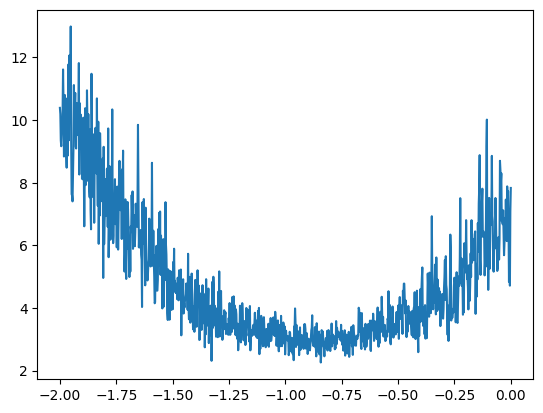

In [191]:
plt.plot(lrei, lossi)

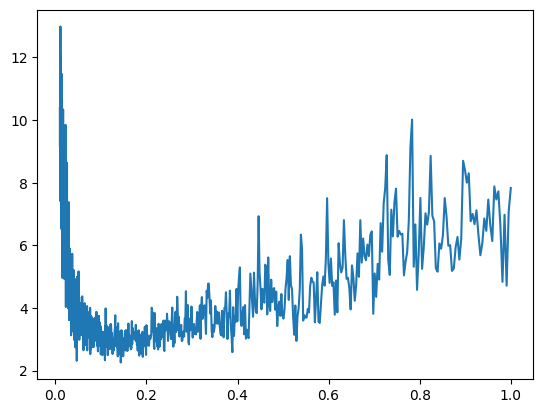

In [192]:
plt.plot(lri, lossi)

In [195]:
# checking the plot for lre we see that -1.0 is a good rate lr = 0.1
for i in range(1000):
    # 
    ix = torch.randint(low=0, high=X.shape[0], size=(32, )) # some small batch
    
    # forward pass
    emb = C[X[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix]) # single number measuring performance
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 # when loss starts to plateau decay by 10x to 0.01
   
    for p in parameters:
        p.data += -lr * p.grad

print(loss.item())

2.7548766136169434


In [196]:
# Loss over all of the dataset
emb = C[X] # shape (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y) # single number measuring performance
print(loss)

tensor(2.6602, grad_fn=<NllLossBackward0>)


##### Split Dataset
This 3K model is a fairly small model. As the capacity of the neural network grows it is capable of overfitting to the dataset. The loss on the training set can get very low - close to zero; but what it is doing is memorizing the data verbatim. If we sample from it this model is capable of giving sample exactly what they were in the training set and nothing new. The loss on a withheld set can be very high (compared to what we see with training set). So just looking at training loss is not a good indicator of how well the model has learned. The standard to deal with this is to split data into: training split, dev or validation split and test split (~80%, 10%, 10%)

Training split is used to train the model. The dev split is used to develop the hyperparameters of the model, example size of the hidden layer-h, size of the embedding-C, strength of regularization. The test split is used to validate the performance of the model at the end, very sparingly or only once.
Everytime we test on the test split and adjust it means we are also learning from it and trying to fit it.

In [47]:
# -------------- Split data -------------------
# build the vocabulary of characters and mappings from/to integers
chs = sorted(set(''.join(words)))
stoi = {s: i+1 for i, s in enumerate(chs)}
stoi['.'] = 0
itos = {i: s for s,i in stoi.items()}
print(itos)

def build_dataset(words):
    # build the training dataset of 3 input characters and next char as target
    block_size = 3 # context length: how many characters do we take to predict the next one?
    xs = []
    ys = []
    for w in words:
        #print(w)
        context = [0] * block_size
        for c in (w + '.'):
            xs.append(context)
            ix = stoi[c]
            ys.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(xs)
    Y = torch.tensor(ys)
    print(X.shape, X.dtype, Y.shape, Y.dtype)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words)) # index of words at 80%
n2 = int(0.9 * len(words)) # index of words at 90%
print(f"train split has {n1} words. Dev split has {n2-n1} words. Test set has {len(words)-n2} words")
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
train split has 25626 words. Dev split has 3203 words. Test set has 3204 words
torch.Size([182441, 3]) torch.int64 torch.Size([182441]) torch.int64
torch.Size([22902, 3]) torch.int64 torch.Size([22902]) torch.int64
torch.Size([22803, 3]) torch.int64 torch.Size([22803]) torch.int64


In [48]:
# Consider C is shared embedding matrix for each character of dimension size 2
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2] # gradient descent on all of them
print(f"number of parameters {sum(p.nelement() for p in parameters)}")

# prepare to learn gradients
for p in parameters:
    p.requires_grad = True


number of parameters 3481


In [16]:
# split dataset and train, validate loss with dev set
losstr = []
lossdev = []
stepi = []
for i in range(10000):
    ix = torch.randint(low=0, high=Xtr.shape[0], size=(32, )) # some small batch
    
    # forward pass
    emb = C[Xtr[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # single number measuring performance
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #track stats
    stepi.append(i)
    losstr.append(loss.item())
    ixd = torch.randint(low=0, high=Xdev.shape[0], size=(32, ))
    logitsdev = (torch.tanh(C[Xdev[ixd]].view(-1, 6) @ W1 + b1)) @ W2 + b2
    lossdev.append(F.cross_entropy(logitsdev, Ydev[ixd]).item())
    # update parameters
    lr = 0.1 # when loss starts to plateau decay by 10x to 0.01
   
    for p in parameters:
        p.data += -lr * p.grad

print(loss.item())
plt.plot(stepi[500:], losstr[500:], label='train loss') # the loss is trashing as the gradient is trashing due to small batch size
plt.plot(stepi[500:], lossdev[500:], label='validation loss')
plt.xlabel('Epoch number')
plt.ylabel('Mean loss')
plt.title('Training loss curve')
plt.legend()

2.615386724472046


Bullets on tuning the model
- Track training, test loss. Regularize to avoid overfitting
- Plot C - embedding in 2D after t-sne or UMAP- without and with regularization
- Tune the model - hidden layer expansion, embedding dimension widening, increase block size of context
- Consider regularization for these updates
- Basically complexify to over fit - regularize - complexify to over fit - add data to underfit
- Rinse repeat as possible
- Increase batch size for smoother descent
- Train over last stage epochs with learning rate decay 10X
- Increase epochs as last step in tuning
- Sample from the NN to check quality of generation and generalization

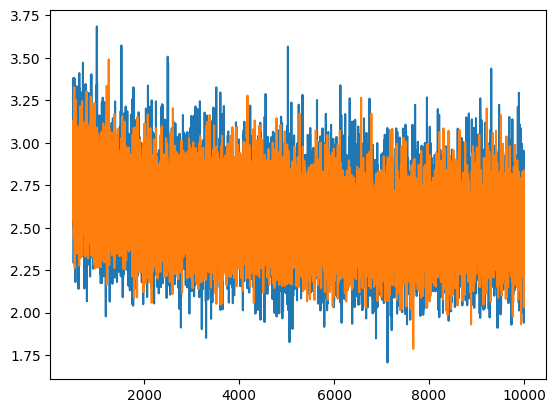

train loss: 2.3871147632598877 validation loss: 2.37522292137146


Text(0.5, 1.0, 'Embedding visualization')

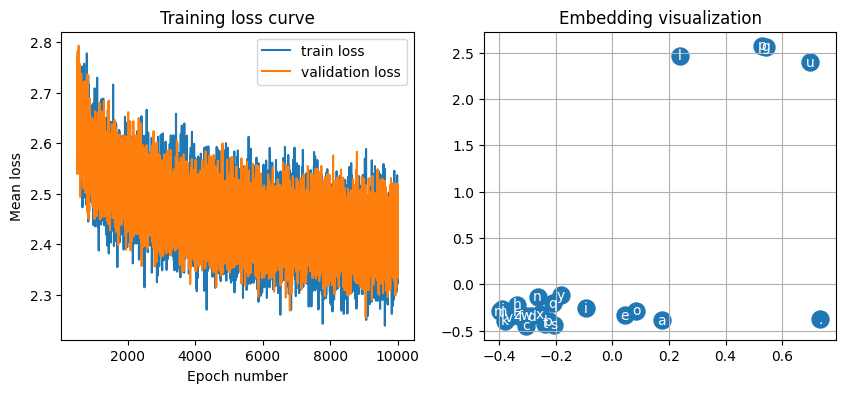

In [49]:
# increase batch size and plot for smoother descent
losstr = []
lossdev = []
stepi = []
for i in range(10000):
    ix = torch.randint(low=0, high=Xtr.shape[0], size=(500, )) # some small batch
    
    # forward pass
    emb = C[Xtr[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (500, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # single number measuring performance
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #track stats
    stepi.append(i)
    losstr.append(loss.item())
    #sample size is higher than training to let loss trash lesser than training, so both are visible
    ixd = torch.randint(low=0, high=Xdev.shape[0], size=(700, )) 
    logitsdev = (torch.tanh(C[Xdev[ixd]].view(-1, 6) @ W1 + b1)) @ W2 + b2
    lossdev.append(F.cross_entropy(logitsdev, Ydev[ixd]).item())
    # update parameters
    lr = 0.1 # when loss starts to plateau decay by 10x to 0.01
   
    for p in parameters:
        p.data += -lr * p.grad

print(f"train loss: {loss.item()} validation loss: {lossdev[-1]}")
# if dev loss is higher than training loss and the absolute difference is > 0.015
if (lossdev[-1] - losstr[-1]) > 0.015:
    print("Model is moving into overfitting zone")
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
ax1.plot(stepi[500:], losstr[500:], label='train loss') # the loss is trashing as the gradient is trashing due to small batch size
ax1.plot(stepi[500:], lossdev[500:], label='validation loss')
ax1.set_xlabel('Epoch number')
ax1.set_ylabel('Mean loss')
ax1.set_title('Training loss curve')
ax1.legend()

ax2.scatter(C[:, 0].data, C[:, 1].detach().numpy(), s=150)
for i in range(C.shape[0]):
    ax2.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
ax2.grid('minor')
ax2.set_title('Embedding visualization')
# The embedding shows the vowels bunched together - model has learned shared behavior between them
# Most of the non-vowels are bunched separately
# The '.' is separate

number of parameters 6881
train loss: 2.3153045177459717 validation loss: 2.4915828704833984
Model is moving into overfitting zone


Text(0.5, 1.0, 'Embedding visualization')

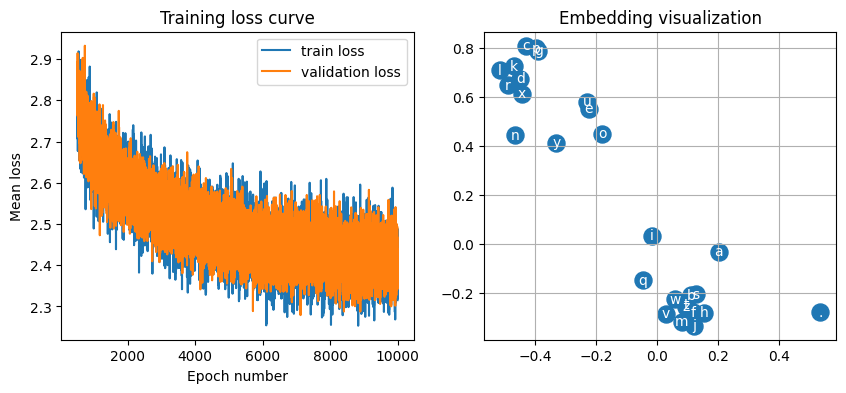

In [50]:
# The plot train loss: 2.423 validation loss: 2.431 above shows that model is not overfitting
# Consider wider hidden layer to complexify the model (this overfits)
# Consider C is shared embedding matrix for each character of dimension size 2
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2] # gradient descent on all of them
print("number of parameters", sum(p.nelement() for p in parameters))

# prepare to learn gradients
for p in parameters:
    p.requires_grad = True

# increase batch size and plot for smoother descent
losstr = []
lossdev = []
stepi = []
for i in range(10000):
    ix = torch.randint(low=0, high=Xtr.shape[0], size=(500, )) # some small batch
    
    # forward pass
    emb = C[Xtr[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # single number measuring performance
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #track stats
    stepi.append(i)
    losstr.append(loss.item())
    ixd = torch.randint(low=0, high=Xdev.shape[0], size=(700, ))
    logitsdev = (torch.tanh(C[Xdev[ixd]].view(-1, 6) @ W1 + b1)) @ W2 + b2
    lossdev.append(F.cross_entropy(logitsdev, Ydev[ixd]).item())
    # update parameters
    lr = 0.1 # when loss starts to plateau decay by 10x to 0.01
   
    for p in parameters:
        p.data += -lr * p.grad

print(f"train loss: {loss.item()} validation loss: {lossdev[-1]}")
# if dev loss is higher than training loss and the absolute difference is > 0.015
if (lossdev[-1] - losstr[-1]) > 0.015:
    print("Model is moving into overfitting zone")
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
ax1.plot(stepi[500:], losstr[500:], label='train loss') # the loss is trashing as the gradient is trashing due to small batch size
ax1.plot(stepi[500:], lossdev[500:], label='validation loss')
ax1.set_xlabel('Epoch number')
ax1.set_ylabel('Mean loss')
ax1.set_title('Training loss curve')
ax1.legend()

ax2.scatter(C[:, 0].data, C[:, 1].detach().numpy(), s=150)
for i in range(C.shape[0]):
    ax2.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
ax2.grid('minor')
ax2.set_title('Embedding visualization')

# train loss: 2.315 validation loss: 2.491 Model overfitting
# The embedding show the vowels and non-vowels separated
# Vowels are bunched together, i,a is separate from e,o,u
# The '.' is separate

number of parameters 6882
train loss: 2.4389374256134033 validation loss: 2.362482786178589
Model is moving into overfitting zone


Text(0.5, 1.0, 'Embedding visualization')

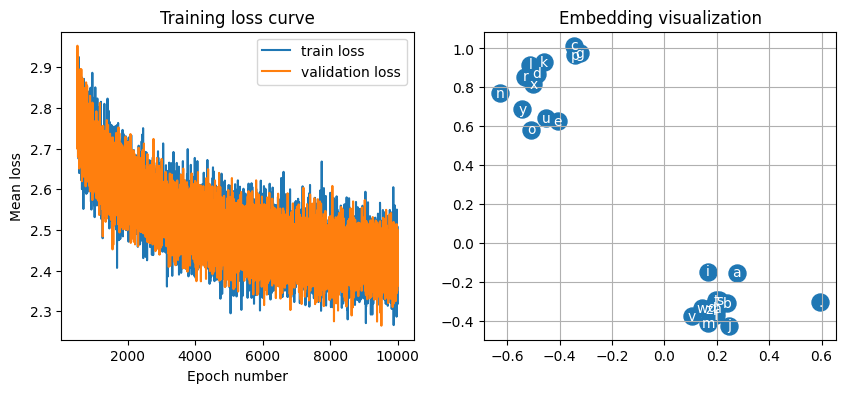

In [58]:
# The plot train loss: 2.398 validation loss: 2.452 shows that model is overfitting with wider hidden layer
# Consider Regularization. C is shared embedding matrix for each character of dimension size 2
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
l2_reg = torch.tensor(0.0) + torch.norm(W1, 2) # regularize weights only of hidden layer not bias
parameters = [C, W1, b1, W2, b2, l2_reg] # gradient descent on all of them
print("number of parameters", sum(p.nelement() for p in parameters))

# prepare to learn gradients
for p in parameters:
    p.requires_grad = True

# increase batch size and plot for smoother descent
losstr = []
lossdev = []
stepi = []
for i in range(10000): # epochs can be increased as the very last step in tuning
    ix = torch.randint(low=0, high=Xtr.shape[0], size=(500, )) # some small batch
    
    # forward pass
    emb = C[Xtr[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) + (0.0001 * l2_reg) # single number measuring performance
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #track stats
    stepi.append(i)
    losstr.append(loss.item())
    ixd = torch.randint(low=0, high=Xdev.shape[0], size=(700, ))
    logitsdev = (torch.tanh(C[Xdev[ixd]].view(-1, 6) @ W1 + b1)) @ W2 + b2
    lossdev.append(F.cross_entropy(logitsdev, Ydev[ixd]).item())
    # update parameters
    lr = 0.1 # when loss starts to plateau decay by 10x to 0.01
   
    for p in parameters:
        p.data += -lr * p.grad

print(f"train loss: {loss.item()} validation loss: {lossdev[-1]}")
# if dev loss is higher than training loss and the absolute difference is > 0.015
if (lossdev[-1] - losstr[-1]) > 0.015:
    print("Model is moving into overfitting zone")
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
ax1.plot(stepi[500:], losstr[500:], label='train loss') # the loss is trashing as the gradient is trashing due to small batch size
ax1.plot(stepi[500:], lossdev[500:], label='validation loss')
ax1.set_xlabel('Epoch number')
ax1.set_ylabel('Mean loss')
ax1.set_title('Training loss curve')
ax1.legend()

ax2.scatter(C[:, 0].data, C[:, 1].detach().numpy(), s=150)
for i in range(C.shape[0]):
    ax2.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
ax2.grid('minor')
ax2.set_title('Embedding visualization')
# with regularization we see the model generalizing better
# train loss: 2.438 validation loss: 2.362
# The embedding show the vowels and non-vowels separated
# Vowels are bunched together, i,a is separate from e,o,u
# The '.' is separate

number of parameters 8136
train loss: 2.3427672386169434 validation loss: 2.3009192943573


Text(0.5, 1.0, 'Embedding: not exact visualization embedding dim is 4')

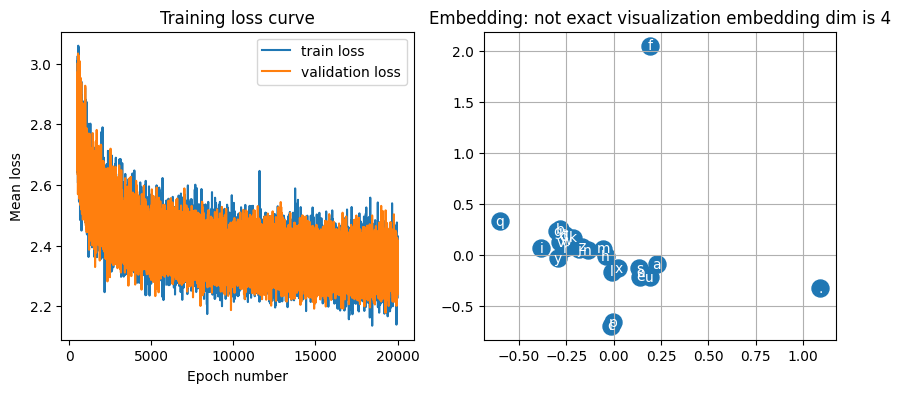

In [59]:
# The plot train loss: 2.438 validation loss: 2.362 above shows that model is not overfitting
# With regularization is generalizing well under wider hidden layer. 
# Sometimes the learning could get stuck due to hidden layer being wide, can help to learn
# , but the embedding size small, being a bottle neck
# C is shared embedding matrix for each character of dimension size 2 - increase its dimensions

g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 4), generator=g) # increased from 2 to 4
W1 = torch.randn((12, 200), generator=g) # increase embedding to 4 
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
l2_reg = torch.tensor(0.0) + torch.norm(W1, 2) # regularize weights only of hidden layer not bias
parameters = [C, W1, b1, W2, b2, l2_reg] # gradient descent on all of them
print("number of parameters", sum(p.nelement() for p in parameters))

# prepare to learn gradients
for p in parameters:
    p.requires_grad = True

# increase batch size and plot for smoother descent
losstr = []
lossdev = []
stepi = []
for i in range(10000): # epochs increased
    ix = torch.randint(low=0, high=Xtr.shape[0], size=(500, )) # some small batch
    
    # forward pass
    emb = C[Xtr[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, 12) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) + (0.0001 * l2_reg) # single number measuring performance
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #track stats
    stepi.append(i)
    losstr.append(loss.item())
    ixd = torch.randint(low=0, high=Xdev.shape[0], size=(700, ))
    logitsdev = (torch.tanh(C[Xdev[ixd]].view(-1, 12) @ W1 + b1)) @ W2 + b2
    lossdev.append(F.cross_entropy(logitsdev, Ydev[ixd]).item())
    # update parameters
    lr = 0.1 # when loss starts to plateau decay by 10x to 0.01
   
    for p in parameters:
        p.data += -lr * p.grad

print(f"train loss: {loss.item()} validation loss: {lossdev[-1]}")
# if dev loss is higher than training loss and the absolute difference is > 0.015
if (lossdev[-1] - losstr[-1]) > 0.015:
    print("Model is moving into overfitting zone")
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
ax1.plot(stepi[500:], losstr[500:], label='train loss') # the loss is trashing as the gradient is trashing due to small batch size
ax1.plot(stepi[500:], lossdev[500:], label='validation loss')
ax1.set_xlabel('Epoch number')
ax1.set_ylabel('Mean loss')
ax1.set_title('Training loss curve')
ax1.legend()

ax2.scatter(C[:, 0].data, C[:, 1].detach().numpy(), s=150)
for i in range(C.shape[0]):
    ax2.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
ax2.grid('minor')
ax2.set_title('Embedding: not exact visualization embedding dim is 4')


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
train split has 25626 words. Dev split has 3203 words. Test set has 3204 words
torch.Size([182484, 4]) torch.int64 torch.Size([182484]) torch.int64
torch.Size([22869, 4]) torch.int64 torch.Size([22869]) torch.int64
torch.Size([22793, 4]) torch.int64 torch.Size([22793]) torch.int64
number of parameters 8936
train loss: 2.3976986408233643 validation loss: 2.2472171783447266


Text(0.5, 1.0, 'Embedding: not exact visualization embedding dim is 4')

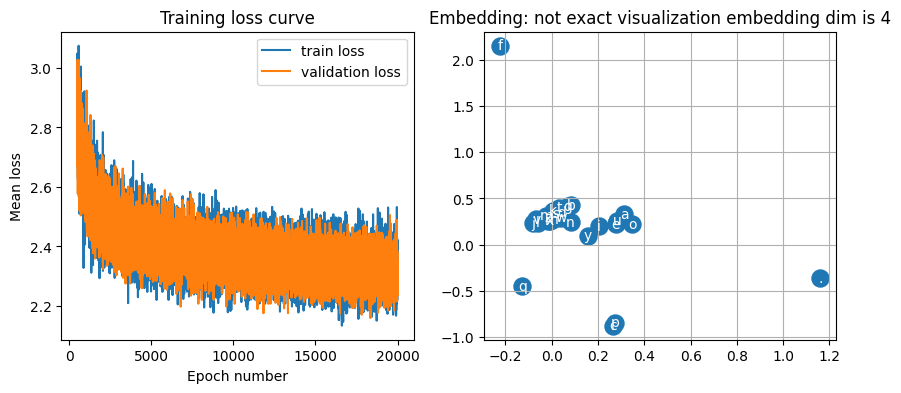

In [63]:
# The plot train loss: 2.342 validation loss: 2.300 above shows that model is not overfitting
# With regularization is learning well under wider hidden layer and increased Embedding dimension C
# Now we can increase the context size to complexify
# Further increase epochs and in the last phase of learning decay learning rate 10X

# -------------- Split data -------------------
# build the vocabulary of characters and mappings from/to integers with bigger context
chs = sorted(set(''.join(words)))
stoi = {s: i+1 for i, s in enumerate(chs)}
stoi['.'] = 0
itos = {i: s for s,i in stoi.items()}
print(itos)
block_size = 4 # context length
emb_size = 4 # embedding per character

def build_dataset(words, block_size):
    # build the training dataset of block_size input characters and next char as target
    block_size = block_size # context length: how many characters do we take to predict the next one?
    xs = []
    ys = []
    for w in words:
        #print(w)
        context = [0] * block_size
        for c in (w + '.'):
            xs.append(context)
            ix = stoi[c]
            ys.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(xs)
    Y = torch.tensor(ys)
    print(X.shape, X.dtype, Y.shape, Y.dtype)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words)) # index of words at 80%
n2 = int(0.9 * len(words)) # index of words at 90%
print(f"train split has {n1} words. Dev split has {n2-n1} words. Test set has {len(words)-n2} words")
Xtr, Ytr = build_dataset(words[:n1], block_size)
Xdev, Ydev = build_dataset(words[n1:n2], block_size)
Xte, Yte = build_dataset(words[n2:], block_size)


g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, emb_size), generator=g) # increased from 2 to 4
W1 = torch.randn((block_size*emb_size, 200), generator=g) # increase embedding to 4 and wider hidden layer, context=4
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
l2_reg = torch.tensor(0.0) + torch.norm(W1, 2) # regularize weights only of hidden layer not bias
parameters = [C, W1, b1, W2, b2, l2_reg] # gradient descent on all of them

print("number of parameters", sum(p.nelement() for p in parameters))

# prepare to learn gradients
for p in parameters:
    p.requires_grad = True

# increase batch size and plot for smoother descent
losstr = []
lossdev = []
stepi = []
for i in range(20000): # epochs increased
    ix = torch.randint(low=0, high=Xtr.shape[0], size=(500, )) # some small batch
    
    # forward pass
    emb = C[Xtr[ix]] # shape (32, 3, 2)
    h = torch.tanh(emb.view(-1, block_size*emb_size) @ W1 + b1) # 12:100::nodim:100 broadcast copy for each row (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) + (0.0001 * l2_reg) # single number measuring performance
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #track stats
    stepi.append(i)
    losstr.append(loss.item())
    ixd = torch.randint(low=0, high=Xdev.shape[0], size=(700, ))
    logitsdev = (torch.tanh(C[Xdev[ixd]].view(-1, block_size*emb_size) @ W1 + b1)) @ W2 + b2
    lossdev.append(F.cross_entropy(logitsdev, Ydev[ixd]).item())
    # update parameters
    lr = 0.1 # when loss starts to plateau decay by 10x to 0.01
   
    for p in parameters:
        p.data += -lr * p.grad

print(f"train loss: {loss.item()} validation loss: {lossdev[-1]}")
# if dev loss is higher than training loss and the absolute difference is > 0.015
if (lossdev[-1] - losstr[-1]) > 0.015:
    print("Model is moving into overfitting zone")
# plot the learning curves and embeddings
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
ax1.plot(stepi[500:], losstr[500:], label='train loss') # the loss is trashing as the gradient is trashing due to small batch size
ax1.plot(stepi[500:], lossdev[500:], label='validation loss')
ax1.set_xlabel('Epoch number')
ax1.set_ylabel('Mean loss')
ax1.set_title('Training loss curve')
ax1.legend()

ax2.scatter(C[:, 0].data, C[:, 1].detach().numpy(), s=150)
for i in range(C.shape[0]):
    ax2.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
ax2.grid('minor')
ax2.set_title('Embedding: not exact visualization embedding dim is 4')

# The model continues to learn well
# there is scope to increase epochs, decay learning rate or before that further complexify

##### Sample from the model to generate new names
Context, embedding size should be same as model

In [67]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10) # change the generator seed
block_size = 4
embed_size = 4
for _ in range(10):
    out = []
    context = [0] * block_size # initialize start token with all ....
    while True:
        # forward pass
        emb = C[torch.tensor([context])] # shape (1, blocksize, embed_size)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) # single example rest of the units to concatenate
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1) # axis = 1
        #print(probs.shape)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0: # index 0 is end token
            break
    print(''.join(out))

mriahamyahzieel.
ndylyah.
rethanlengrlen.
azerydieli.
jeli.
jelle.
elivan.
narleltynor.
karin.
shubvrishi.
